# OASIS Cross-Sectional Dataset — Distribution & Feature Analysis

**Goal:** Examine the distribution of each key clinical/imaging variable, compare them across diagnosis groups, and identify which features are most likely to be useful for Alzheimer's Disease classification.

**Note on `Group`:** This dataset has no ready-made diagnosis label. As established in the initial EDA, `Group` is derived from `CDR`:
- `CDR = 0` → **Nondemented**
- `CDR > 0` (0.5 / 1 / 2) → **Demented**
- `CDR` missing → **Unknown** (not clinically assessed; excluded from group comparisons below)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

PALETTE = {"Nondemented": "#2E86AB", "Demented": "#E63946", "Unknown": "#A8A8A8"}
GROUP_ORDER = ["Nondemented", "Demented", "Unknown"]


In [2]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df_clinical = df[df["Group"] != "Unknown"].copy()  # subjects with a known diagnosis

print(f"Full dataset: {df.shape[0]} subjects")
print(f"Clinically assessed (known diagnosis): {df_clinical.shape[0]} subjects")
df.head()


Full dataset: 436 subjects
Clinically assessed (known diagnosis): 235 subjects


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Group
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,Nondemented
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,Nondemented
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,Demented
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN,Unknown
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN,Unknown


## 1. Age Distribution

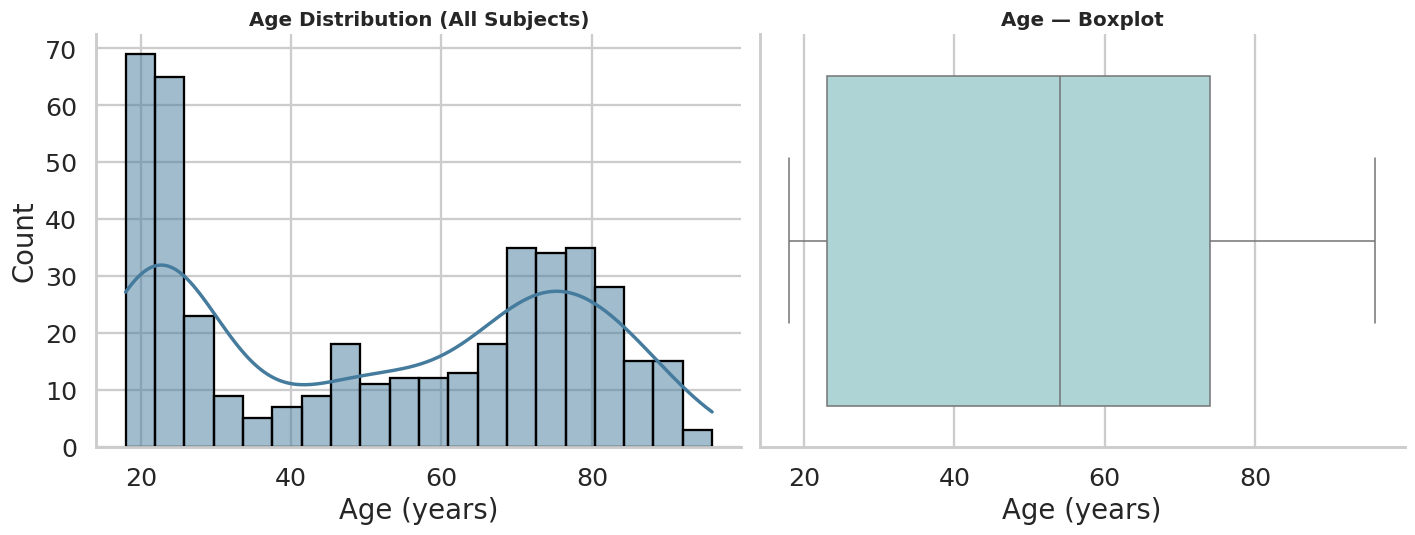

count    436.000000
mean      51.357798
std       25.269862
min       18.000000
25%       23.000000
50%       54.000000
75%       74.000000
max       96.000000
Name: Age, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Age"], bins=20, kde=True, color="#457B9D", edgecolor="black", ax=axes[0])
axes[0].set_title("Age Distribution (All Subjects)")
axes[0].set_xlabel("Age (years)")

sns.boxplot(x=df["Age"], color="#A8DADC", ax=axes[1])
axes[1].set_title("Age — Boxplot")
axes[1].set_xlabel("Age (years)")

sns.despine()
plt.tight_layout()
plt.show()

print(df["Age"].describe())


**Observation:** Age shows a bimodal-leaning spread across roughly 18–96 years, reflecting OASIS's deliberate pooling of young healthy controls with an older clinical cohort. No extreme outliers are visible in the boxplot. Because age strongly confounds brain structure measures, any model using volumetric features should treat age as a covariate rather than ignore it.

## 2. MMSE Distribution

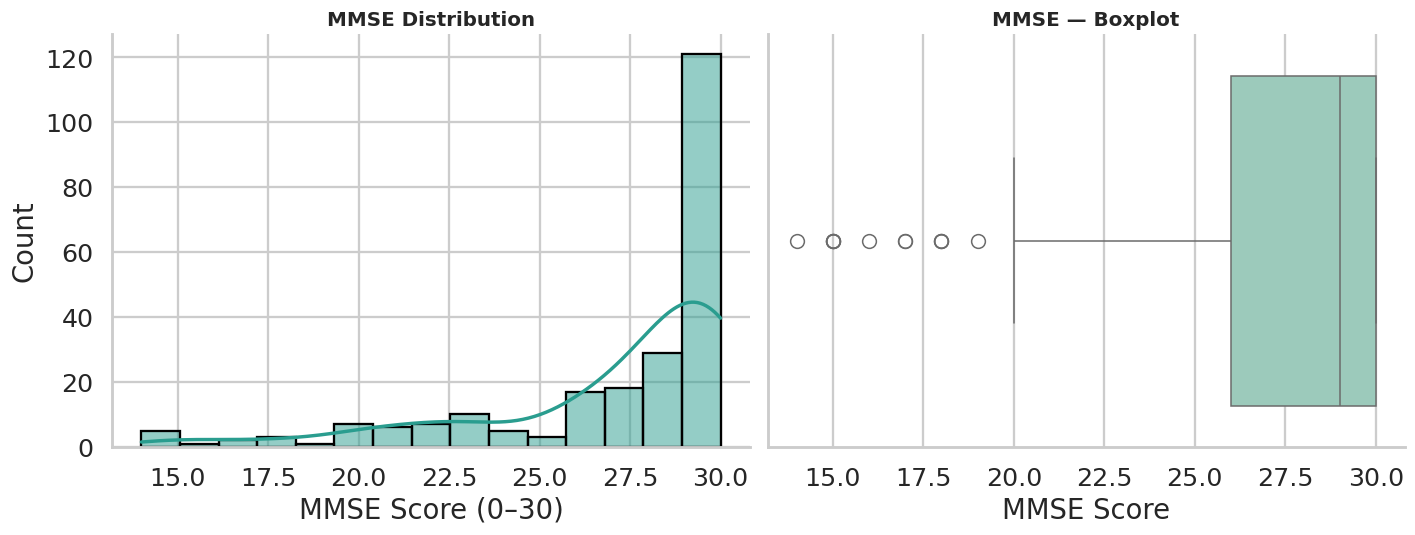

count    235.00000
mean      27.06383
std        3.69687
min       14.00000
25%       26.00000
50%       29.00000
75%       30.00000
max       30.00000
Name: MMSE, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["MMSE"].dropna(), bins=15, kde=True, color="#2A9D8F", edgecolor="black", ax=axes[0])
axes[0].set_title("MMSE Distribution")
axes[0].set_xlabel("MMSE Score (0–30)")

sns.boxplot(x=df["MMSE"].dropna(), color="#94D2BD", ax=axes[1])
axes[1].set_title("MMSE — Boxplot")
axes[1].set_xlabel("MMSE Score")

sns.despine()
plt.tight_layout()
plt.show()

print(df["MMSE"].describe())


**Observation:** MMSE is heavily left-skewed, with most clinically assessed subjects scoring near the ceiling (27–30), and a long tail of low scorers reflecting more severe cognitive impairment. The boxplot's low-end outliers correspond to subjects with marked cognitive decline. This skew suggests MMSE may need transformation or robust scaling if used as a continuous model input, though it remains one of the most direct cognitive markers available.

## 3. CDR Distribution

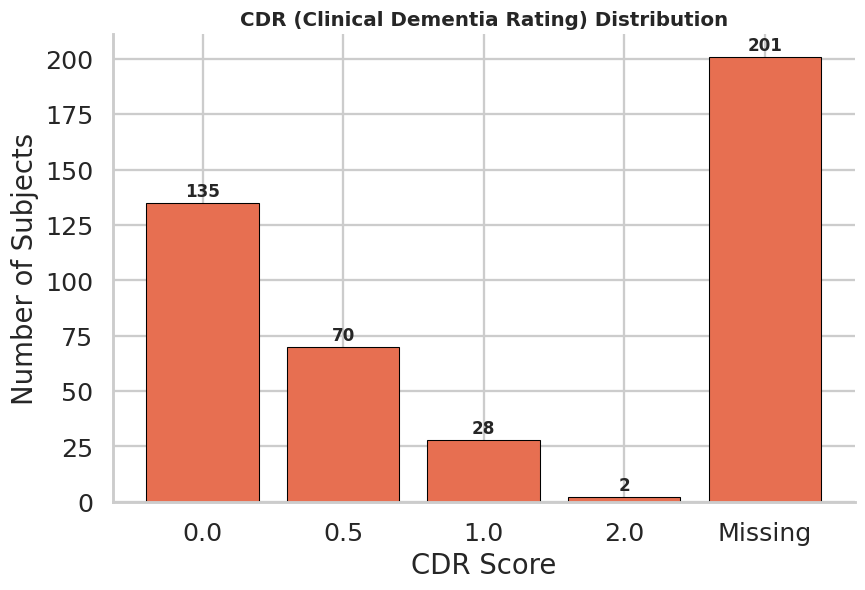

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cdr_counts = df["CDR"].value_counts(dropna=False).sort_index()
cdr_labels = [str(c) if pd.notna(c) else "Missing" for c in cdr_counts.index]

bars = ax.bar(cdr_labels, cdr_counts.values, color="#E76F51", edgecolor="black", linewidth=0.7)
ax.set_title("CDR (Clinical Dementia Rating) Distribution")
ax.set_xlabel("CDR Score")
ax.set_ylabel("Number of Subjects")
for bar, v in zip(bars, cdr_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 3, str(v), ha="center", fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()


**Observation:** CDR is heavily concentrated at 0 (no dementia) among assessed subjects, with progressively fewer subjects at 0.5 (very mild), 1 (mild), and 2 (moderate) — a pattern consistent with population-level dementia prevalence. This confirms substantial class imbalance for any Demented/Nondemented classifier and suggests CDR=2 (moderate) cases may be too sparse for reliable subgroup analysis on their own.

## 4. eTIV Distribution

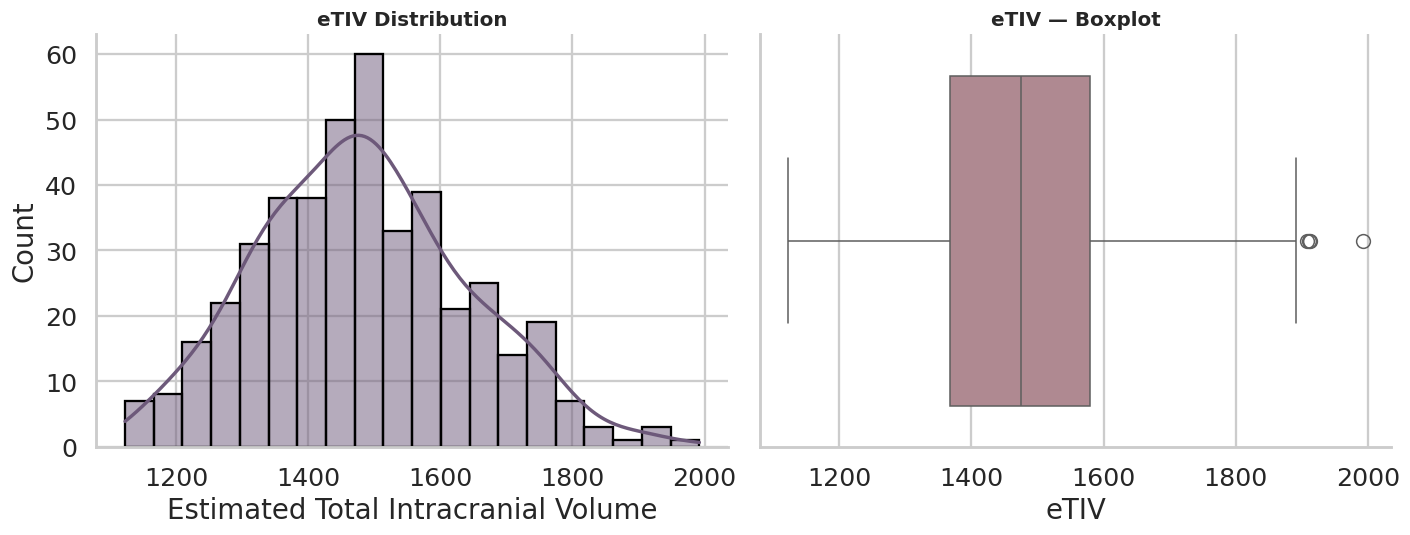

count     436.000000
mean     1481.919725
std       158.740866
min      1123.000000
25%      1367.750000
50%      1475.500000
75%      1579.250000
max      1992.000000
Name: eTIV, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["eTIV"], bins=20, kde=True, color="#6D597A", edgecolor="black", ax=axes[0])
axes[0].set_title("eTIV Distribution")
axes[0].set_xlabel("Estimated Total Intracranial Volume")

sns.boxplot(x=df["eTIV"], color="#B5838D", ax=axes[1])
axes[1].set_title("eTIV — Boxplot")
axes[1].set_xlabel("eTIV")

sns.despine()
plt.tight_layout()
plt.show()

print(df["eTIV"].describe())


**Observation:** eTIV is approximately bell-shaped, reflecting natural variation in head/skull size across the population, primarily driven by sex and body size rather than disease status. Since intracranial volume doesn't shrink with disease (unlike brain tissue itself), eTIV mainly serves as a normalization factor for other volumetric measures rather than a direct disease marker.

## 5. nWBV Distribution

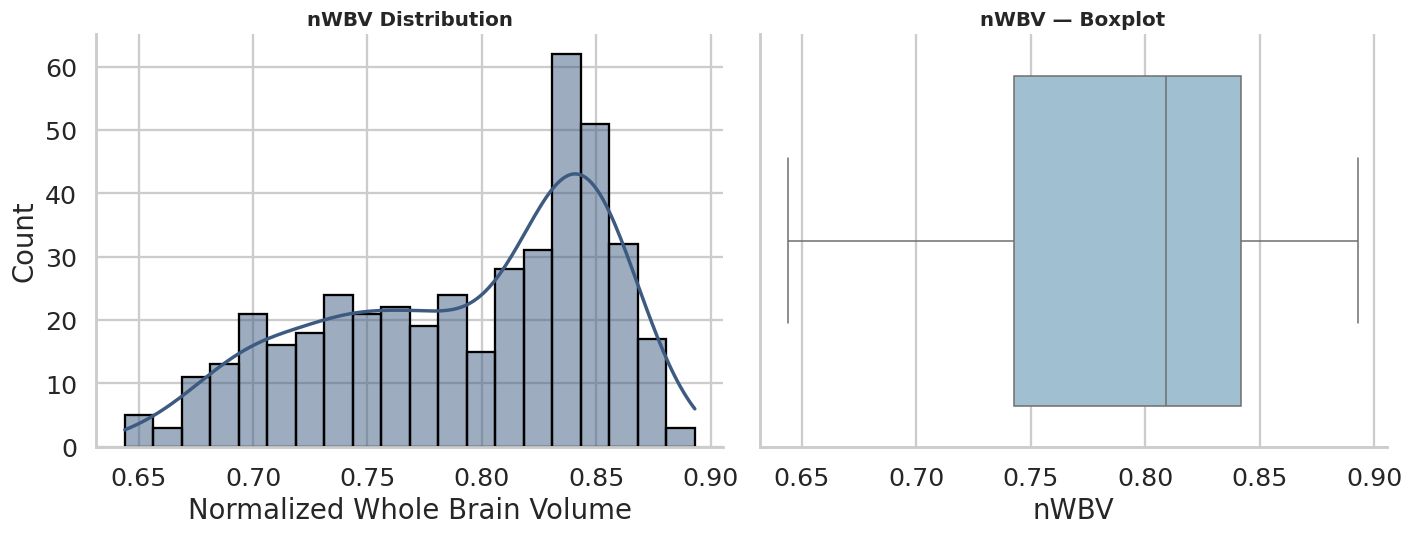

count    436.000000
mean       0.791670
std        0.059937
min        0.644000
25%        0.742750
50%        0.809000
75%        0.842000
max        0.893000
Name: nWBV, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["nWBV"], bins=20, kde=True, color="#3D5A80", edgecolor="black", ax=axes[0])
axes[0].set_title("nWBV Distribution")
axes[0].set_xlabel("Normalized Whole Brain Volume")

sns.boxplot(x=df["nWBV"], color="#98C1D9", ax=axes[1])
axes[1].set_title("nWBV — Boxplot")
axes[1].set_xlabel("nWBV")

sns.despine()
plt.tight_layout()
plt.show()

print(df["nWBV"].describe())


**Observation:** nWBV is fairly continuous and slightly left-skewed, consistent with a mix of younger subjects with well-preserved brain volume and older/affected subjects showing atrophy. Because nWBV directly captures brain tissue loss — a hallmark of neurodegeneration — it is one of the strongest candidate imaging biomarkers for distinguishing dementia status, which we examine further in the group comparison below.

## 6. ASF Distribution

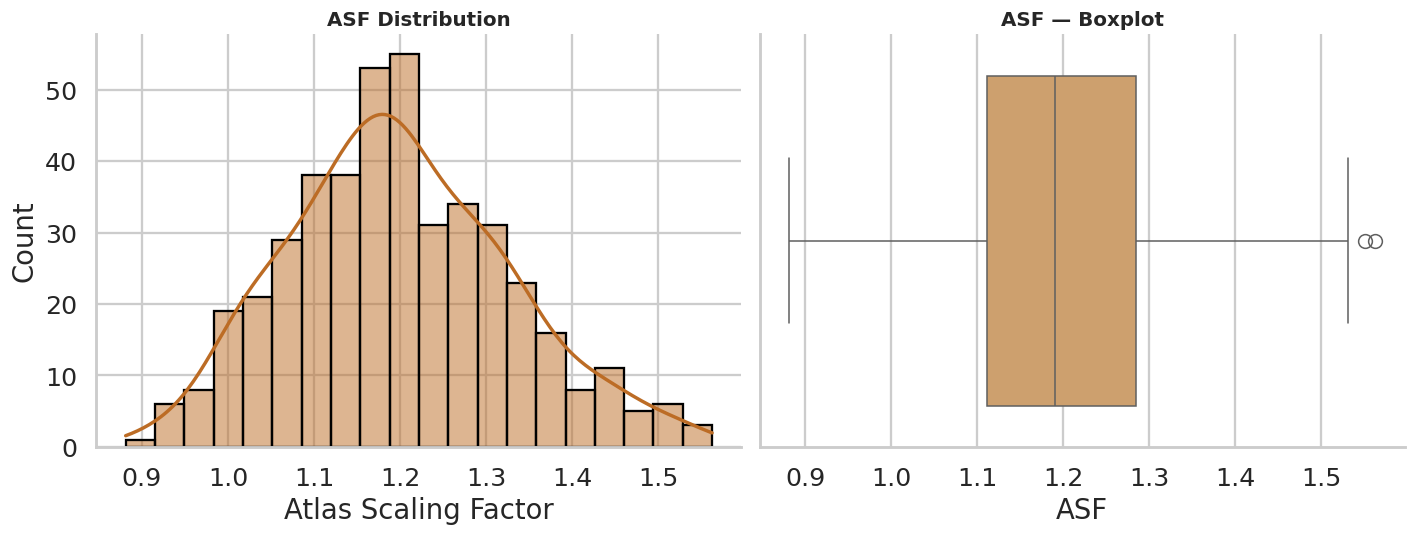

count    436.000000
mean       1.198894
std        0.128682
min        0.881000
25%        1.111750
50%        1.190000
75%        1.284250
max        1.563000
Name: ASF, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["ASF"], bins=20, kde=True, color="#BC6C25", edgecolor="black", ax=axes[0])
axes[0].set_title("ASF Distribution")
axes[0].set_xlabel("Atlas Scaling Factor")

sns.boxplot(x=df["ASF"], color="#DDA15E", ax=axes[1])
axes[1].set_title("ASF — Boxplot")
axes[1].set_xlabel("ASF")

sns.despine()
plt.tight_layout()
plt.show()

print(df["ASF"].describe())


**Observation:** ASF distribution mirrors eTIV in inverse form (ASF is derived to normalize each subject's brain to a standard atlas), confirming it carries largely the same information as eTIV. Including both eTIV and ASF as separate model features would likely introduce multicollinearity without adding new signal.

## 7. Distribution Comparison Across Diagnosis Groups

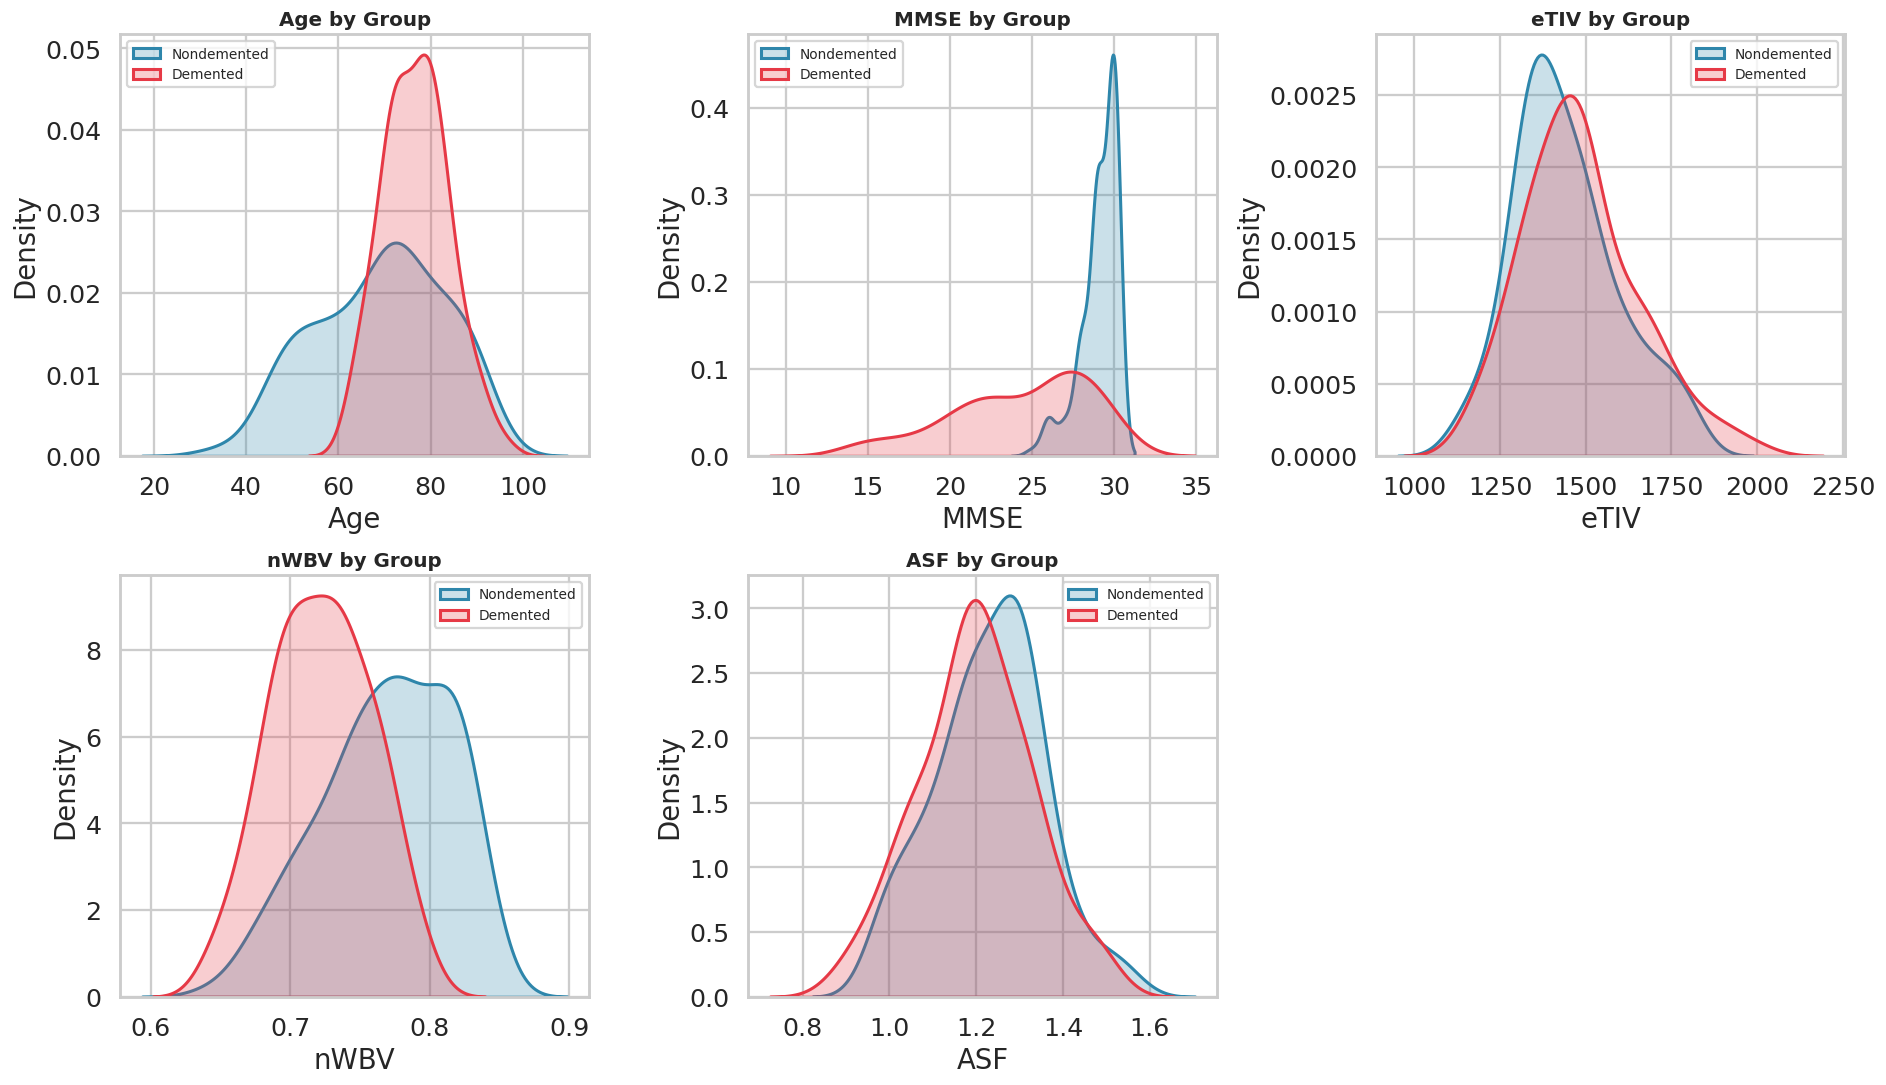

In [9]:
numeric_features = ["Age", "MMSE", "eTIV", "nWBV", "ASF"]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    for grp in ["Nondemented", "Demented"]:
        subset = df_clinical[df_clinical["Group"] == grp][feat].dropna()
        sns.kdeplot(subset, label=grp, fill=True, alpha=0.25, linewidth=2,
                    color=PALETTE[grp], ax=axes[i])
    axes[i].set_title(f"{feat} by Group")
    axes[i].legend(fontsize=9)

axes[-1].axis("off")  # unused 6th subplot
plt.tight_layout()
plt.show()


In [10]:
# Statistical comparison: Mann-Whitney U test (non-parametric, robust to skew/outliers)
print(f"{'Feature':<10} {'Nondem. Median':<16} {'Dem. Median':<14} {'p-value':<10}")
print("-" * 55)
for feat in numeric_features:
    a = df_clinical[df_clinical["Group"] == "Nondemented"][feat].dropna()
    b = df_clinical[df_clinical["Group"] == "Demented"][feat].dropna()
    stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{feat:<10} {a.median():<16.3f} {b.median():<14.3f} {p:<10.2e} {sig}")


Feature    Nondem. Median   Dem. Median    p-value   
-------------------------------------------------------
Age        71.000           77.000         2.66e-05   ***
MMSE       29.000           26.000         5.04e-25   ***
eTIV       1415.000         1464.000       5.18e-02   ns
nWBV       0.773            0.722          5.06e-14   ***
ASF        1.240            1.199          5.16e-02   ns


**Observation:** MMSE and nWBV show the clearest separation between Nondemented and Demented groups, both visually (minimal KDE overlap) and statistically (very low p-values), making them the strongest individual discriminators in this set. Age also differs significantly between groups, consistent with dementia risk rising with age, while eTIV and ASF — being skull-size–driven rather than disease-driven — show the weakest separation, reinforcing that they are normalization variables rather than diagnostic markers in their own right.

## 8. Boxplots for All Numerical Features

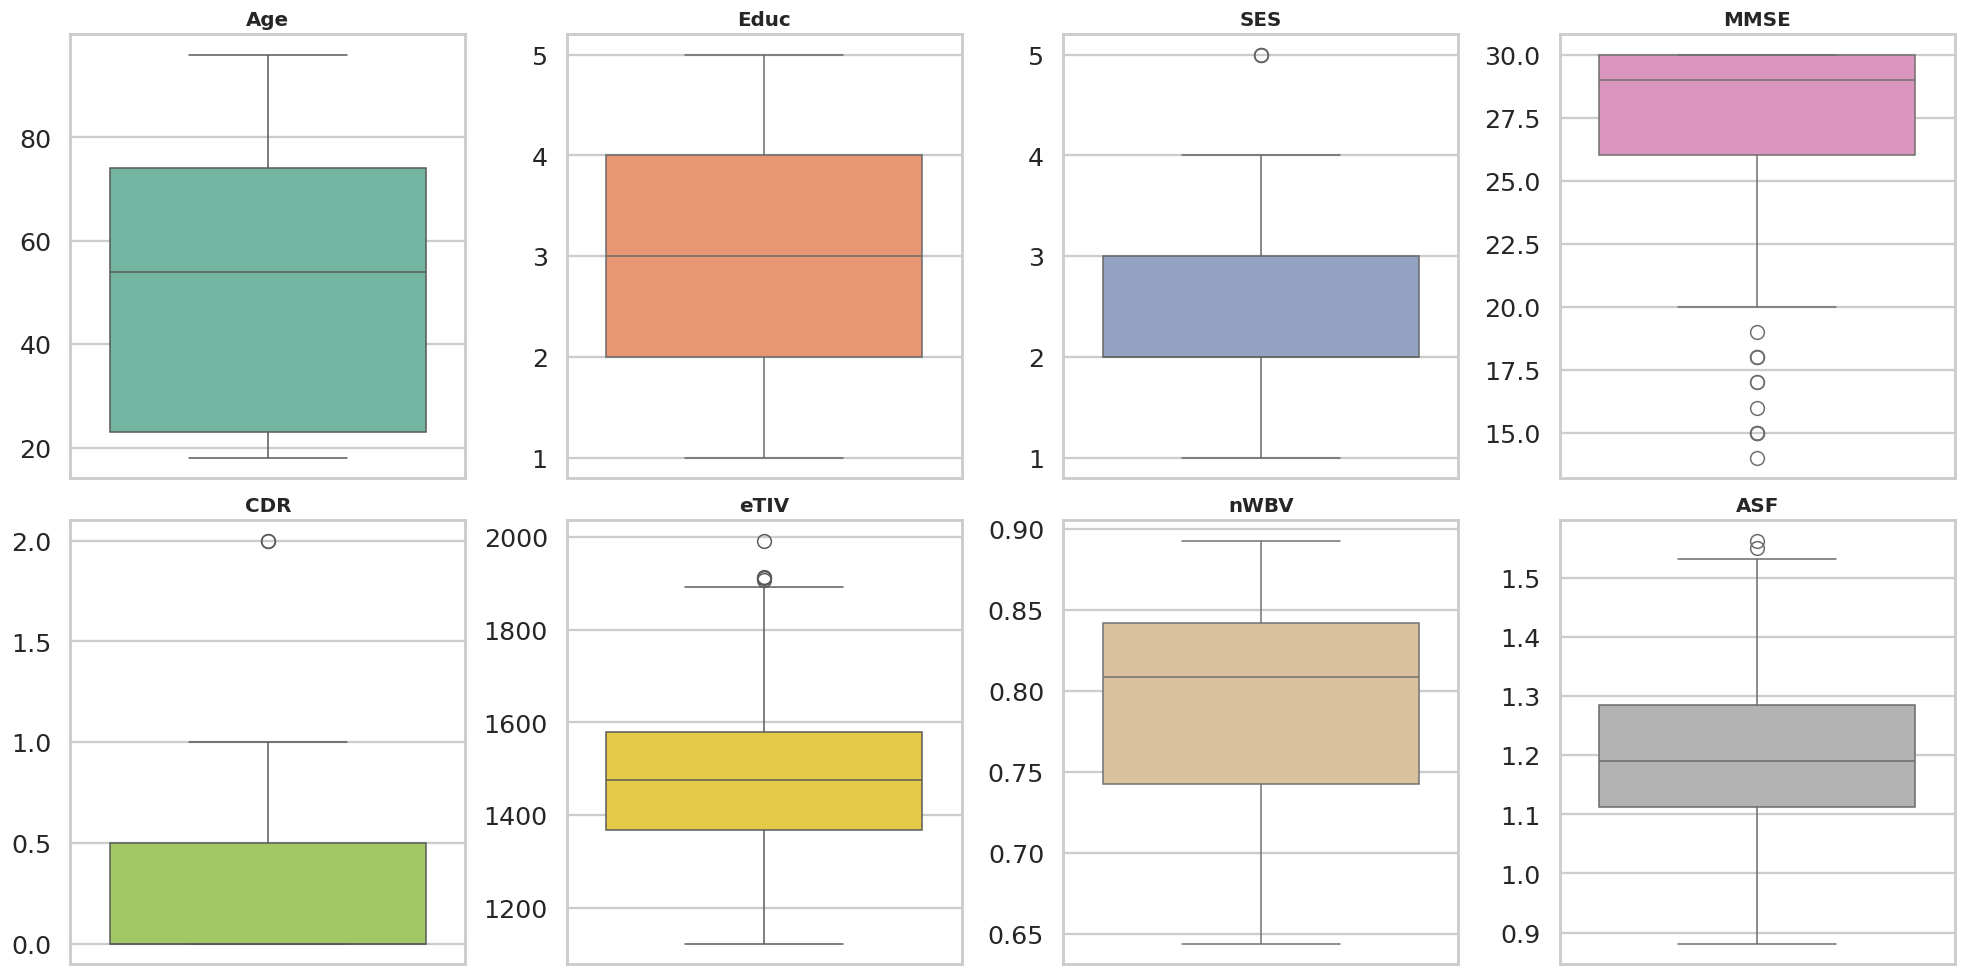

In [11]:
all_numeric = ["Age", "Educ", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(all_numeric):
    sns.boxplot(y=df[feat].dropna(), color=sns.color_palette("Set2")[i % 8], ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()


**Observation:** Most features show modest, expected spread with few extreme outliers, suggesting the dataset is reasonably clean. `SES` and `Educ` are ordinal/categorical-like with a small number of discrete levels, so their boxplots are less informative than for continuous variables — these may be better visualized as bar counts. `CDR`'s boxplot is dominated by the 0 majority class, visually compressing the non-zero scores, which is consistent with the imbalance already noted in Section 3.

## 9. Correlation Heatmap

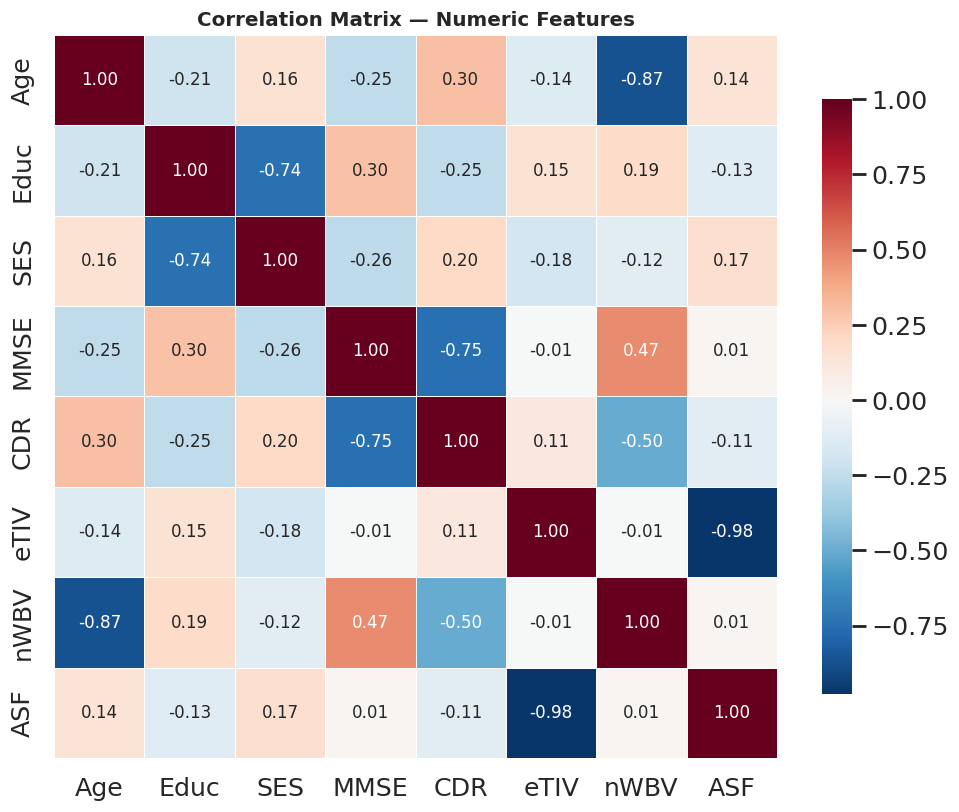

In [12]:
corr_features = ["Age", "Educ", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


**Observation:** `eTIV` and `ASF` show a very strong negative correlation (near -1), confirming they encode essentially the same information and should not both be included as independent model inputs. `CDR` correlates negatively with `MMSE` and `nWBV`, reinforcing both as disease-relevant features identified earlier. `SES` and `Educ` show a moderate relationship with each other, as expected socioeconomically, but weaker direct correlation with `CDR`, suggesting limited standalone diagnostic value.

## 10. Identifying Potentially Important Features

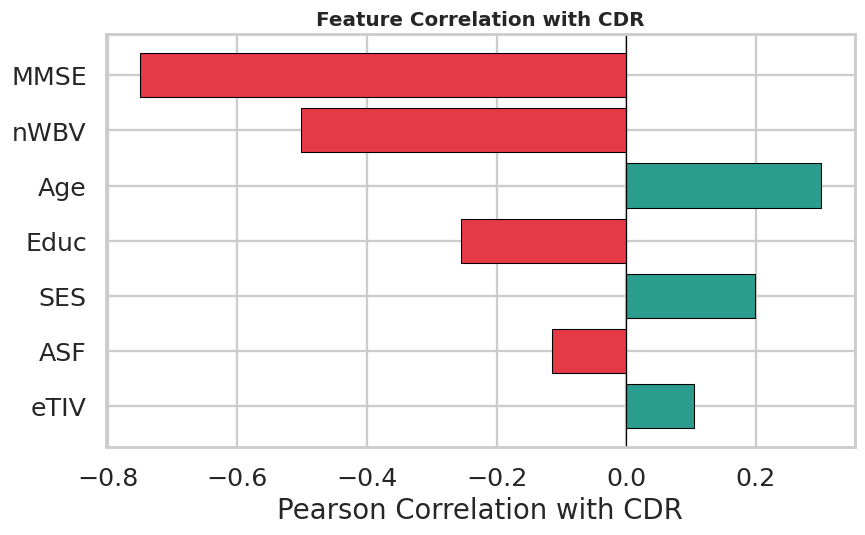

MMSE   -0.750070
nWBV   -0.501014
Age     0.299969
Educ   -0.254745
SES     0.198240
ASF    -0.114299
eTIV    0.105204
Name: CDR, dtype: float64

In [13]:
# Rank features by |correlation| with CDR (severity) as a proxy for diagnostic relevance
cdr_corr = df[corr_features].corr()["CDR"].drop("CDR").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E63946" if v < 0 else "#2A9D8F" for v in cdr_corr.values]
ax.barh(cdr_corr.index, cdr_corr.values, color=colors, edgecolor="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with CDR")
ax.set_xlabel("Pearson Correlation with CDR")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

cdr_corr


**Observation:** Based on correlation strength with CDR and the group-wise separation seen in Section 7, `MMSE` and `nWBV` emerge as the most promising individual predictive features, with `Age` as a relevant secondary factor. `eTIV` and `ASF` are not meaningfully associated with disease severity and are better treated as normalization variables (or dropped to avoid redundancy) rather than predictive features. `SES` and `Educ` show weak association with CDR in this dataset and are lower-priority candidates, though they may still interact with other variables and shouldn't be discarded without further multivariate testing (e.g. feature importance from a trained model).

**Summary of candidate feature tiers:**
- **High priority:** `MMSE`, `nWBV`
- **Moderate priority:** `Age`
- **Low priority / normalization-only:** `eTIV`, `ASF` (keep one, drop the other)
- **Exploratory / weak signal alone:** `SES`, `Educ` — worth retaining for multivariate models but unlikely to be strong solo predictors
